In [ ]:
import os
import sys
sys.path.append(os.path.expanduser('~'))
import numpy as np 
import numba as nb
import time
import importlib
import json
import argparse
import h5py
from matplotlib import pyplot as plt
from datetime import datetime as dt

from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils

from scipy.optimize import minimize,check_grad,least_squares
from scipy.ndimage import median_filter 
from skyfield.api import load, wgs84

import helper_discrepancies as hd
import helper_finetiming as hf
import figures as fgs

sys.path.append(os.path.expanduser('~'))

In [ ]:
path_config = "/home/thomasb/albatros_analysis/scripts/orbcomm/config/config_batch1.json"

with open(path_config, "r") as f:
    config = json.load(f)
antpos=[]
for i, (ant, details) in enumerate(config["antennas"].items()):
        antpos.append(details["coordinates"])
print(antpos)

batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
osamp = config['correlation']['osamp']
acclen = config['correlation']['new_acclen']
print(batch_start_ts)

T_SPECTRA = 4096/250e6 * osamp
print(T_SPECTRA)

[[79.41717895, -90.76721818, 188.095], [79.41721848, -90.75872502, 183.51076468], [79.38845797, -91.01936185, 19.777], [79.4183154, -90.667425, 59.364], [79.3979952, -90.799868, 42.692], [79.41148497, -90.69528512, 32.593], [79.44377162, -90.71824306, 416.829]]
1753132820
0.001048576


In [15]:
path_batch = f'/scratch/thomasb/batch_{batch_start_ts}'

fname_pulses = "data/pulses.json"
path_pulses = os.path.join(path_batch, fname_pulses)
fname_cutter = "data/cutting.json"
path_cutter = os.path.join(path_batch, fname_cutter)

# fname_map = 'timing_discrepancies/times_all_incoherent.json'
# path_map = os.path.join(path_batch, fname_map)

In [16]:
with open(path_pulses, "r") as f_pulses:
        pulse_list = json.load(f_pulses)
with open(path_cutter, "r") as f_cutter:
        cutter_dict = json.load(f_cutter)
# with open(path_map, "r") as f_map:
#         map_dict = json.load(f_map)

In [51]:
idx_pulse = 2

#extract from pulses json
pulse = pulse_list[idx_pulse]
print(pulse)

pulse_start_ts = pulse['t_start']
pulse_end_ts = pulse['t_end']
satID = pulse['sat']
chan_det = pulse['channel']
print('detection channel', chan_det)

tle_path = outils.get_tle_file(pulse_start_ts, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

ant_idxs = [0, 2, 3, 4, 5, 6]
ant_nums = [1, 2, 4, 5, 6, 7, 8]

if chan_det%2 == 0:
    chans_old = np.arange(chan_det-2, chan_det+2) + 1834
else:
    chans_old = np.arange(chan_det-1, chan_det+3) + 1834

print(chans_old)

{'antenna': 'Antenna 2', 'sat': 59051, 'channel': 3, 't_start': 1753136743, 't_end': 1753137136, 'len': 393}
detection channel 3
[1836 1837 1838 1839]


In [52]:
fname_data = f"data_raw_osamp=64_start={pulse_start_ts}_end={pulse_end_ts}_chans={chans_old[0]}:{chans_old[-1]}.npy"

#extract from cutter json
cut = cutter_dict[fname_data]

data_all = np.load(os.path.join(path_batch, 'data', fname_data))
print(data_all.shape)

(7, 2, 374784, 256)


In [57]:
data = data_all[:, :, :, :100]

chans_new = np.arange(0, 100)
nchans = len(chans_new)
print(nchans)

freqs = (chans_new/64 + chans_old[0])*250e6/4096
freqs = 250e6-freqs

100


In [ ]:
n_blines = len(ant_idxs)*(len(ant_idxs)-1)//2

multi_vis = np.zeros((n_blines, data.shape[2]//acclen, data.shape[3]), dtype='complex64', order='c')
print("multi_vis shape", multi_vis.shape)

bl_proc=0
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            a1_coords=antpos[ai]
            a2_coords=antpos[aj]
            dly = outils.get_sat_delay(
                                a1_coords,
                                a2_coords,
                                tle_path,
                                pulse_start_ts,
                                int(pulse_end_ts - pulse_start_ts)+2,  #BEWARE maybe the fitting messed this up
                                satID,
                                altaz=False
                            )
            delay = np.interp(
                np.arange(0, data.shape[2]) * T_SPECTRA, np.arange(0, int(pulse_end_ts - pulse_start_ts)+2), dly
            )
            spec1=data[ai,0,:,:]
            spec2=data[aj,0,:,:]
            spec2_phased = np.empty_like(spec2)
            # print("spec2", spec2_phased.shape)
            # print(spec2_phased.flags)
            spec2_phased = hd.apply_delay(spec2, spec2_phased, -delay, freqs)
            Vxx = hd.xcorr_avg(spec1,spec2_phased,acclen)
            spec1=data[ai,1,:,:]
            spec2=data[aj,1,:,:]
            spec2_phased = np.empty_like(spec2)
            spec2_phased = hd.apply_delay(spec2, spec2_phased, -delay, freqs)
            Vyy = hd.xcorr_avg(spec1,spec2_phased,acclen)
            multi_vis[bl_proc,:,:] = (Vxx+Vyy)/2
            bl_proc+=1
            print("done", ai,aj,".Processed",bl_proc, "baselines")

multi_vis shape (15, 366, 100)
catalog #59051 epoch 2025-07-21 22:07:03 UTC
one delay prediction: 0.20855307579040527
done 0 2 .Processed 1 baselines
catalog #59051 epoch 2025-07-21 22:07:03 UTC
one delay prediction: 0.20756769180297852
done 0 3 .Processed 2 baselines
catalog #59051 epoch 2025-07-21 22:07:03 UTC
one delay prediction: 0.20627951622009277
done 0 4 .Processed 3 baselines
catalog #59051 epoch 2025-07-21 22:07:03 UTC
one delay prediction: 0.21004366874694824
done 0 5 .Processed 4 baselines
catalog #59051 epoch 2025-07-21 22:07:03 UTC
one delay prediction: 0.2085564136505127
done 0 6 .Processed 5 baselines
catalog #59051 epoch 2025-07-21 22:07:03 UTC
one delay prediction: 0.2089247703552246
done 2 3 .Processed 6 baselines
catalog #59051 epoch 2025-07-21 22:07:03 UTC
one delay prediction: 0.2142949104309082
done 2 4 .Processed 7 baselines
catalog #59051 epoch 2025-07-21 22:07:03 UTC
one delay prediction: 0.20565390586853027
done 2 5 .Processed 8 baselines
catalog #59051 epoch

15
(15, 366, 100)


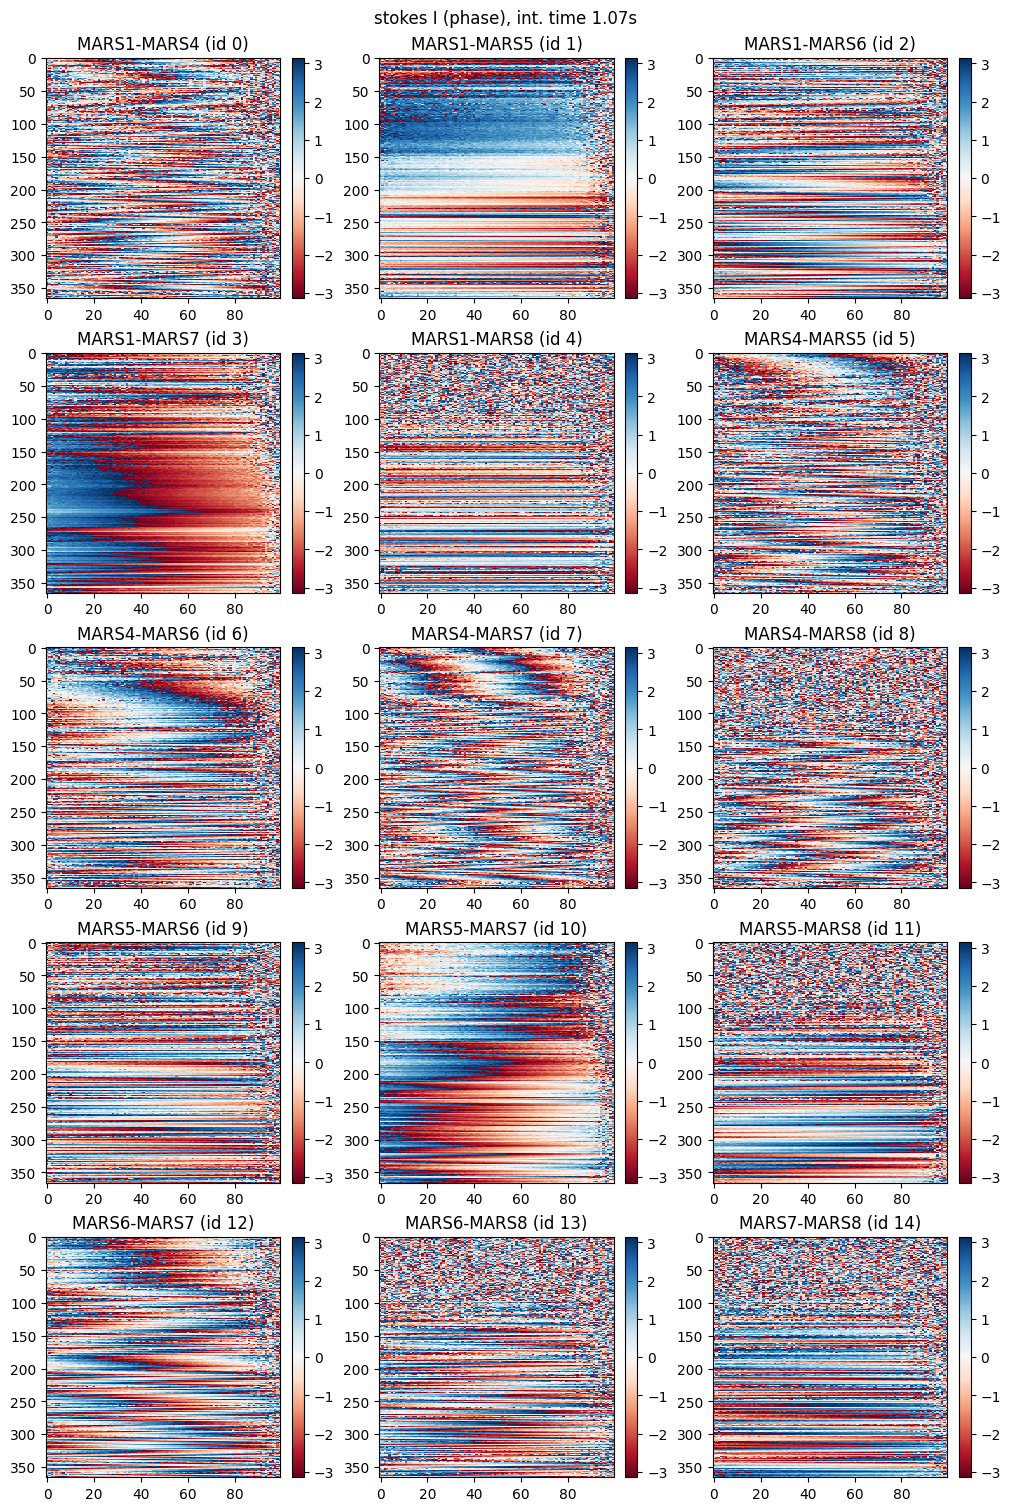

In [59]:
#generate phase plots for each baseline
nant=7
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(5,3, constrained_layout=True)
fig.set_size_inches(10,15)
ax=np.ravel(ax)
pnum=0
print(n_blines)
plt.suptitle(f"stokes I (phase), int. time {T_SPECTRA*acclen:4.2f}s")
x = np.arange(data.shape[3])
thermal_noise = np.zeros((n_blines, multi_vis.shape[1]),dtype='float64')
vis_noise = np.zeros((n_blines, multi_vis.shape[1]),dtype='float64')
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            ax[pnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {pnum})")
            a=np.unwrap(np.angle(multi_vis[pnum,:,:]),axis=1)
            for k in range(a.shape[0]):
                m, c = np.polyfit(x, a[k,:], 1)
                residual = a[k,:] - (m*x + c)
                # sigma_phi = np.sqrt(np.mean(residual**2))
                sigma_phi = np.std(np.angle(np.exp(1j*residual)))
                thermal_noise[pnum,k] = sigma_phi
                vis_noise[pnum,k] = np.std(np.cos(residual))
            b=np.unwrap(a,axis=0)
            img=ax[pnum].imshow(np.angle(multi_vis[pnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
            cbar=plt.colorbar(img,ax=ax[pnum])
            #ax[pnum].set_ylim(cut_end, cut_start)
            pnum+=1
# plt.tight_layout()
print(multi_vis.shape)

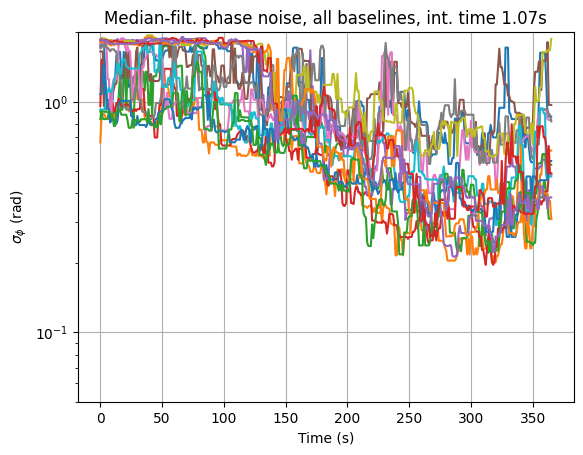

In [60]:
for bl in range(n_blines):
    plt.semilogy(median_filter(thermal_noise[bl,:],10),label=f'bl id {bl}')
plt.title(f"Median-filt. phase noise, all baselines, int. time {T_SPECTRA*acclen:4.2f}s")
plt.ylabel("$\sigma_\phi$ (rad)")
plt.xlabel("Time (s)")
plt.ylim(0.05,2)
plt.grid(True)